<div dir="rtl">

# DBSCAN بخش ۳: تنظیم min_samples

در این نوت‌بوک eps رو ثابت نگه می‌داریم و min_samples رو تغییر میدیم تا اثر خالص min_samples و حساسیت مدل به اون دیده بشه.
داده مثل نوت‌بوک‌های قبلی آماده شده و همان نمونه ۵۰ هزارتایی گرفته شده.

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
df = pd.read_parquet("../data/Divar_cleaned.parquet")

is_sell = df["cat2_slug"].str.contains("sell", na=False).fillna(False).astype(bool)
is_full_credit = (df["inferred_full_credit"] == True).fillna(False).astype(bool)

df["unified_price"] = np.select(
    [is_sell, is_full_credit],
    [df["price_value"], df["transformable_credit"]],
    default=df["transformed_credit"],
)
df["unified_price"] = df["unified_price"].replace(0, np.nan)

features = ["location_utm_x", "location_utm_y", "unified_price"]
data = df[features + ["city_slug", "cat2_slug"]].dropna(subset=features).copy()

def is_fake_price(price):
    digits = str(int(price))
    return len(digits) >= 6 and len(set(digits)) == 1

data = data[~data["unified_price"].apply(is_fake_price)]
data["log_price"] = np.log1p(data["unified_price"])
low, high = data["log_price"].quantile([0.01, 0.99])
data = data[data["log_price"].between(low, high)].copy()

X_scaled = StandardScaler().fit_transform(data[["location_utm_x", "location_utm_y", "log_price"]])

rng = np.random.RandomState(42)
pos = rng.choice(len(data), 50_000, replace=False)
sample = data.iloc[pos].copy()
X_sample = X_scaled[pos]

print(f"dade tamiz: {len(data):,} | nemoone: {len(sample):,}")

dade tamiz: 425,471 | nemoone: 50,000


<div dir="rtl">

## ۲. انتخاب مستقل eps

eps ر, از نتیجه نوت‌بوک ۲ نگرفتم و با یک روش جدا از خود داده درآوردیم. برای هر نقطه فاصله تا ششمین همسایه‌اش رو حساب کردیم. عدد ۶ دو برابر تعداد ویژگی‌هاست و کمترین مقدار رایج min_samples است. بعد eps ر, صدک ۹۵ این فاصله‌ها گذاشتیم یعنی شعاعی که ۹۵ درصد نقطه‌ها در آن حداقل ۶ همسایه دارن .
نتیجه eps برابر ۰.۱۶۳ شد.

</div>

eps sabet (sadak 95 fasele ta hamsaye 6om): 0.163


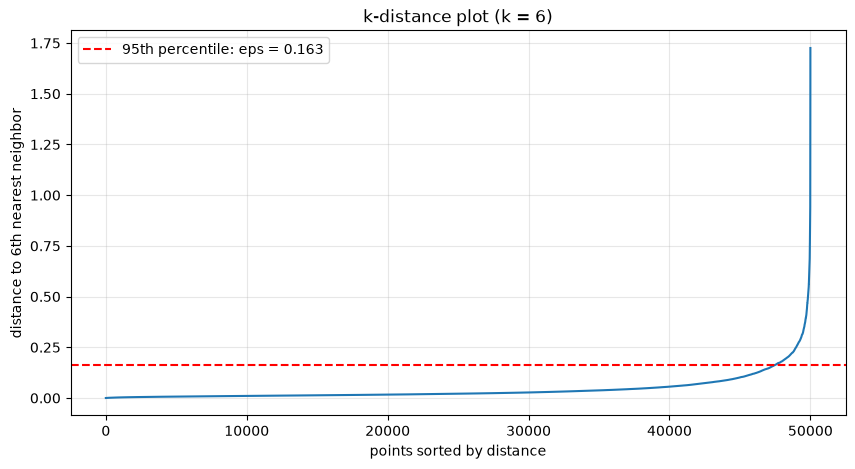

In [2]:
from sklearn.neighbors import NearestNeighbors
k = 6
nn = NearestNeighbors(n_neighbors=k).fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])

eps_fixed = round(float(np.percentile(k_dist, 95)), 3)
print(f"eps sabet (sadak 95 fasele ta hamsaye {k}om): {eps_fixed}")

plt.figure(figsize=(10, 5))
plt.plot(k_dist)
plt.axhline(eps_fixed, color="red", linestyle="--", label=f"95th percentile: eps = {eps_fixed}")
plt.title(f"k-distance plot (k = {k})")
plt.xlabel("points sorted by distance")
plt.ylabel(f"distance to {k}th nearest neighbor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div dir="rtl">

## ۳. امتحان min_samples های مختلف

min_samplesهرا از ۳ تا ۲۰۰ تغییر دادیم. مثل نوت‌بوک ۲ خوشه‌ای ر. معنادار حساب کردیم که حداقل ۱ درصد نمونه رو داشته باشه 

</div>

In [3]:
min_samples_values = [3, 5, 8, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200]
big_limit = int(len(sample) * 0.01)
rows = []
for ms in min_samples_values:
    labels = DBSCAN(eps=eps_fixed, min_samples=ms).fit_predict(X_sample)
    sizes = pd.Series(labels[labels != -1]).value_counts()
    noise = (labels == -1).sum()
    big = sizes[sizes >= big_limit]

    rows.append({
        "min_samples": ms,
        "clusters": len(sizes),
        "big_clusters": len(big),
        "big_sizes_%": list((big / len(sample) * 100).round(1)),
        "noise_count": noise,
        "noise_%": round(noise / len(sample) * 100, 2),
    })
    print(f"min_samples={ms} anjam shod")

ms_results = pd.DataFrame(rows)
ms_results

min_samples=3 anjam shod
min_samples=5 anjam shod
min_samples=8 anjam shod
min_samples=10 anjam shod
min_samples=15 anjam shod
min_samples=20 anjam shod
min_samples=30 anjam shod
min_samples=40 anjam shod
min_samples=50 anjam shod
min_samples=75 anjam shod
min_samples=100 anjam shod
min_samples=150 anjam shod
min_samples=200 anjam shod


,min_samples,clusters,big_clusters,big_sizes_%,noise_count,noise_%
0,3,231,5,"[78.0, 5.9, 3.2, 2.1, 1.2]",797,1.59
1,5,125,6,"[72.9, 5.9, 4.9, 3.2, 2.1, 1.2]",1398,2.80
2,8,82,7,"[68.1, 5.9, 4.9, 3.2, 3.0, 1.6, 1.2]",2270,4.54
3,10,59,8,"[64.4, 5.9, 4.9, 3.4, 3.2, 2.9, 1.6, 1.2]",2843,5.69
4,15,46,10,"[62.1, 5.8, 4.8, 3.2, 2.9, 1.7, 1.5, 1.5, 1.3,...",4000,8.00
5,20,44,10,"[60.1, 5.8, 4.8, 3.1, 2.8, 1.5, 1.5, 1.4, 1.2,...",4956,9.91
6,30,32,10,"[58.4, 5.7, 4.7, 3.1, 2.7, 1.4, 1.4, 1.1, 1.1,...",6651,13.30
7,40,25,9,"[58.0, 5.6, 4.6, 3.0, 2.7, 1.4, 1.2, 1.1, 1.0]",8006,16.01
8,50,20,9,"[46.7, 10.7, 5.5, 4.6, 3.0, 2.6, 1.3, 1.2, 1.0]",9414,18.83
9,75,17,7,"[46.5, 5.3, 4.9, 4.9, 4.3, 2.7, 2.4]",11995,23.99


<div dir="rtl">

## ۴. اثر min_samples

min_samples تعداد همسایه‌ای است که یک نقطه لازم دارد تا هسته خوشه باشد. هر چه بزرگ‌تر باشد نقطه‌های بیشتری Noise می‌شوند. برای همین Noise از ۱.۶ درصد تا ۳۷ درصد بالا رفت.
با min_samples کوچک هر چند آگهی نزدیک به هم یک خوشه ریز می‌سازند و ۲۳۱ خوشه داشتیم. با بزرگ شدن آن این خوشه‌های ریز حذف شدند و تا ۸ خوشه کم شدند. بزرگ‌ترین خوشه هم از ۷۸ درصد به ۴۶ درصد رسید چون نقطه‌هایی که مناطق را به هم وصل می‌کردند Noise شدند.

با این eps تعداد خوشه‌های معنادار هیچ‌وقت به ۳ نرسید و بین ۵ و ۱۰ ماند.

</div>

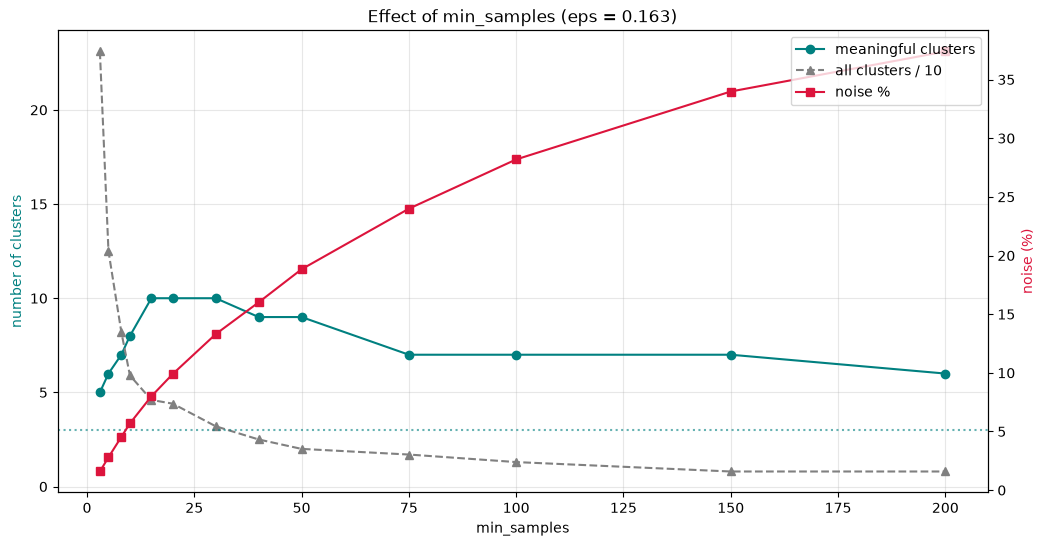

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(ms_results["min_samples"], ms_results["big_clusters"], marker="o", color="teal", label="meaningful clusters")
ax1.plot(ms_results["min_samples"], ms_results["clusters"] / 10, marker="^", color="gray", linestyle="--", label="all clusters / 10")
ax1.axhline(3, color="teal", linestyle=":", alpha=0.6)
ax1.set_xlabel("min_samples")
ax1.set_ylabel("number of clusters", color="teal")

ax2 = ax1.twinx()
ax2.plot(ms_results["min_samples"], ms_results["noise_%"], marker="s", color="crimson", label="noise %")
ax2.set_ylabel("noise (%)", color="crimson")

ax1.set_title(f"Effect of min_samples (eps = {eps_fixed})")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
ax1.grid(alpha=0.3)
plt.show()

<div dir="rtl">

## ۵. حساسیت مدل

برای سنجیدن حساسیت از Adjusted Rand Index استفاده کردیم که دو خوشه‌بندی رو مقایسه می‌کند. عدد ۱ یعنی کاملا یکین و ۰ یعنی هیچ شباهتی ندارن با هم . برای هر دو min_samples پشت سر هم ARI رو حساب کردیم.

</div>

In [5]:
from sklearn.metrics import adjusted_rand_score

all_labels = {ms: DBSCAN(eps=eps_fixed, min_samples=ms).fit_predict(X_sample) for ms in min_samples_values}

stability = pd.DataFrame([
    {"az": a, "be": b, "ARI": round(adjusted_rand_score(all_labels[a], all_labels[b]), 3)}
    for a, b in zip(min_samples_values[:-1], min_samples_values[1:])
])
stability

,az,be,ARI
0,3,5,0.847
1,5,8,0.865
2,8,10,0.901
3,10,15,0.933
4,15,20,0.942
5,20,30,0.938
6,30,40,0.973
7,40,50,0.734
8,50,75,0.921
9,75,100,0.933


<div dir="rtl">

## نتیجه

مدل در کل نسبت به min_samples پایدار است و ARI بیشتر جاها بالای ۰.۸۵ است. یعنی تغییر min_samples بیشتر حاشیه خوشه‌ها و Noise رو عوض می‌کند نه ساختار اصلی .

حساس‌ترین نقطه بین ۴۰ و ۵۰ است که ARI به ۰.۷۳ رسید. همان جایی که خوشه اصلی خراب شد . پایدارترین بازه بین ۱۵ و ۴۰ است.

پیشنهاد ما min_samples برابر ۲۰ است. تا اینجا بیشتر خوشه‌های ریز بی‌معنی حذف شده‌اند و Noise هنوز زیر ۱۰ درصد است و وسط بازه پایدار هم هست. این عدد با روشی جدا به دست آمد ولی با مقداری که نوت‌بوک ۲ فرض کرده بود یکیست.

یافته مهم این است که با eps ثابت فقط با تغییر min_samples به ۳ خوشه معنادار نمی‌رسیم. پس تعداد خوشه‌ها بیشتر به eps حساس است و min_samples بیشتر مقدار Noise رو کنترل می‌کند. برای رسیدن به ۳ خوشه باید هر دو رو با هم تنظیم کنیم که کار نوت‌بوک ۴ است.

</div>